In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hussainnasirkhan/flair-brats2020/FLAIR_BRATS2020_split/val/images/image_200.npy
/kaggle/input/datasets/hussainnasirkhan/flair-brats2020/FLAIR_BRATS2020_split/val/images/image_273.npy
/kaggle/input/datasets/hussainnasirkhan/flair-brats2020/FLAIR_BRATS2020_split/val/images/image_202.npy
/kaggle/input/datasets/hussainnasirkhan/flair-brats2020/FLAIR_BRATS2020_split/val/images/image_301.npy
/kaggle/input/datasets/hussainnasirkhan/flair-brats2020/FLAIR_BRATS2020_split/val/images/image_75.npy
/kaggle/input/datasets/hussainnasirkhan/flair-brats2020/FLAIR_BRATS2020_split/val/images/image_345.npy
/kaggle/input/datasets/hussainnasirkhan/flair-brats2020/FLAIR_BRATS2020_split/val/images/image_110.npy
/kaggle/input/datasets/hussainnasirkhan/flair-brats2020/FLAIR_BRATS2020_split/val/images/image_277.npy
/kaggle/input/datasets/hussainnasirkhan/flair-brats2020/FLAIR_BRATS2020_split/val/images/image_130.npy
/kaggle/input/datasets/hussainnasirkhan/flair-brats2020/FLAIR_BRATS2020_sp

Device: cuda
Found text directory: /kaggle/input/datasets/cs23b2016kishorek/textbrats/TextBRats/TextBraTSData (369 patients)


Loading text data:   0%|          | 0/369 [00:00<?, ?it/s]

Loaded 369 raw texts


Computing CLIP embeddings:   0%|          | 0/369 [00:00<?, ?it/s]

Computed 369 CLIP embeddings (dim=torch.Size([512]))
Model architecture defined.
Loaded multimodal checkpoint from /kaggle/input/datasets/kishoreirene/dl-best-path/best_multimodal.pth
Text corpus: 369 patients
Index-to-patient mapping: 369 entries
  Example: 0 → BraTS20_Training_001, 1 → BraTS20_Training_002, 100 → BraTS20_Training_101


Indexing:   0%|          | 0/86 [00:00<?, ?it/s]

  Total samples: 86
  Example: ('/kaggle/input/datasets/hussainnasirkhan/flair-brats2020/FLAIR_BRATS2020_split/val/images/image_100.npy', '/kaggle/input/datasets/hussainnasirkhan/flair-brats2020/FLAIR_BRATS2020_split/val/masks/mask_100.npy', 'BraTS20_Training_101')


Text Generation:   0%|          | 0/6 [00:00<?, ?it/s]


TEXT GENERATION EVALUATION RESULTS
Samples evaluated: 86
BLEU-4:  0.2224 +/- 0.0517
ROUGE-L: 0.4323 +/- 0.0424
PREDICTED vs GROUND TRUTH RADIOLOGY TEXT COMPARISONS

────────────────────────────────────────────────────────────────────────────────────────────────────
  SAMPLE 1 | Patient: BraTS20_Training_101
  BLEU-4: 0.1892 | ROUGE-L: 0.3946 | Similarity: 0.9045
────────────────────────────────────────────────────────────────────────────────────────────────────

  GROUND TRUTH:
  The lesion area is primarily located in the left frontal and temporal lobes with a mix of heterogeneous high and low signals, along with patchy areas of high signal, suggesting multiple lesions. Edema is prominently seen around the left frontal lobe with extensive edema in the surrounding tissue, extending to the frontal lobe and part of the parietal lobe, showing a large area of tissue swelling. Necrosis is possibly indicated in the central region of the lesion by marked low signal intensity, w

  PREDICTED:

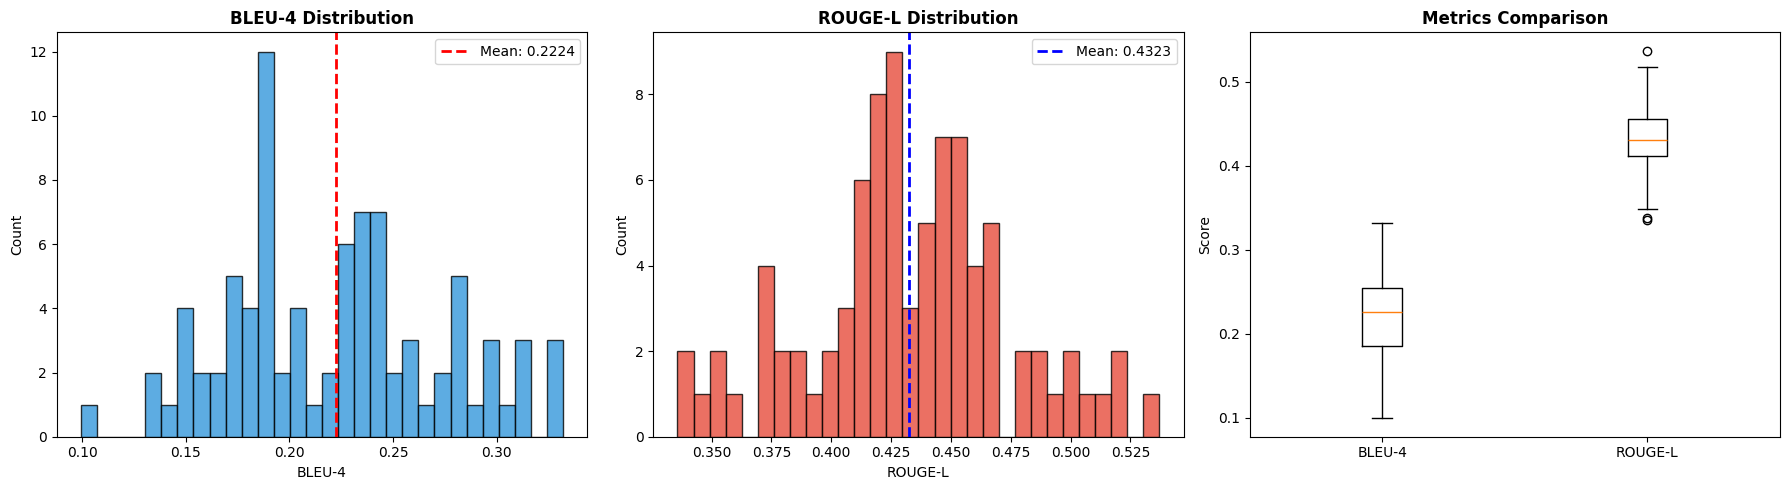

Saved: text_generation_metrics.png


In [13]:
    # %% [markdown]
    # # Text Generation Evaluation Notebook
    # ## Multimodal Brain Tumor Segmentation - Text Quality Assessment
    # 
    # This notebook loads pre-trained multimodal model, evaluates text generation
    # quality using BLEU-4 and ROUGE-L metrics, and displays 5 sample comparisons
    # between predicted and ground truth radiology texts.

    # %% [markdown]
    # ## 1. Install Dependencies & Imports

    # %%
    !pip install -q open_clip_torch

    # %%
    import os, gc, math, random, glob, warnings, subprocess
    import numpy as np
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    from torchvision import models
    from collections import Counter
    from tqdm.auto import tqdm
    from PIL import Image
    import matplotlib.pyplot as plt

    warnings.filterwarnings("ignore")

    # %% [markdown]
    # ## 2. Configuration

    # %%
    class CFG:
        DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
        IMG_SIZE = 224
        TEXT_DIM = 512
        BS = 16
        SEED = 42
        
        # Dataset paths
        TEXT_DIR = "/kaggle/input/datasets/cs23b2016kishorek/textbrats/TextBRats/TextBraTSData"
        FLAIR_TRAIN = "/kaggle/input/datasets/hussainnasirkhan/flair-brats2020/FLAIR_BRATS2020_split/train"
        FLAIR_VAL = "/kaggle/input/datasets/hussainnasirkhan/flair-brats2020/FLAIR_BRATS2020_split/val"
        
        # Model checkpoint paths
        MM_CKPT = "/kaggle/input/datasets/kishoreirene/dl-best-path/best_multimodal.pth"
        IMG_CKPT = "/kaggle/input/datasets/kishoreirene/best-image-only/best_image_only.pth"
        
        OUT = "/kaggle/working"

    print(f"Device: {CFG.DEVICE}")

    # %% [markdown]
    # ## 3. Locate Text Directory & Load Text Data + Embeddings

    # %%
    # Find the text directory - try multiple possible mount paths
    possible_text_dirs = [
        CFG.TEXT_DIR,
        "/kaggle/input/textbrats/TextBRats/TextBraTSData",
        "/kaggle/input/textbrats/TextBraTSData",
    ]

    text_dir_found = None
    for td in possible_text_dirs:
        if os.path.exists(td):
            sample_dirs = [d for d in os.listdir(td) if d.startswith("BraTS20")]
            if len(sample_dirs) > 0:
                text_dir_found = td
                print(f"Found text directory: {td} ({len(sample_dirs)} patients)")
                break

    if text_dir_found is None:
        # Fallback: search recursively
        result = subprocess.run(["find", "/kaggle/input", "-name", "*flair_text.txt", "-type", "f"],
                            capture_output=True, text=True, timeout=60)
        found_files = result.stdout.strip().split("\n") if result.stdout.strip() else []
        print(f"Searched recursively, found {len(found_files)} text files")
        if found_files and found_files[0]:
            text_dir_found = os.path.dirname(os.path.dirname(found_files[0]))
            print(f"Derived text dir: {text_dir_found}")

    assert text_dir_found is not None, "ERROR: Could not find text data directory!"

    # %%
    # Load raw texts (skip .npy — they are 768-dim, model needs 512-dim)
    raw_texts = {}
    patient_dirs = sorted([d for d in os.listdir(text_dir_found) if d.startswith("BraTS20")])

    for pid in tqdm(patient_dirs, desc="Loading text data"):
        txt_path = os.path.join(text_dir_found, pid, f"{pid}_flair_text.txt")
        if os.path.exists(txt_path):
            with open(txt_path) as f:
                raw_texts[pid] = f.read().strip()

    print(f"Loaded {len(raw_texts)} raw texts")

    # Compute 512-dim CLIP ViT-B-32 embeddings from raw text
    import open_clip
    clip_model, _, _ = open_clip.create_model_and_transforms("ViT-B-32", pretrained="laion2b_s34b_b79k")
    clip_model = clip_model.to(CFG.DEVICE).eval()
    tokenizer = open_clip.get_tokenizer("ViT-B-32")

    text_embeddings = {}
    for pid in tqdm(raw_texts.keys(), desc="Computing CLIP embeddings"):
        tokens = tokenizer([raw_texts[pid]]).to(CFG.DEVICE)
        with torch.no_grad():
            emb = clip_model.encode_text(tokens)
            emb = emb / emb.norm(dim=-1, keepdim=True)
        text_embeddings[pid] = emb.cpu().squeeze(0)

    del clip_model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    print(f"Computed {len(text_embeddings)} CLIP embeddings (dim={text_embeddings[list(text_embeddings.keys())[0]].shape})")

    # %% [markdown]
    # ## 4. BLEU-4 and ROUGE-L Metric Functions

    # %%
    def compute_bleu(reference, candidate, max_n=4):
        """Compute smoothed BLEU-4 score (Chen & Cherry, 2014)."""
        ref_tokens = reference.lower().split()
        cand_tokens = candidate.lower().split()
        if len(cand_tokens) == 0:
            return 0.0
        precisions = []
        for n in range(1, max_n + 1):
            ref_ngrams = Counter([tuple(ref_tokens[i:i+n]) for i in range(len(ref_tokens)-n+1)])
            cand_ngrams = Counter([tuple(cand_tokens[i:i+n]) for i in range(len(cand_tokens)-n+1)])
            clipped = sum(min(cand_ngrams[ng], ref_ngrams[ng]) for ng in cand_ngrams)
            total = max(sum(cand_ngrams.values()), 1)
            # Add-epsilon smoothing to avoid zero precision killing the score
            eps = 1.0 / (2 ** n)  # decreasing smoothing for higher n-grams
            precisions.append((clipped + eps) / (total + eps))
        log_avg = sum(math.log(p) for p in precisions) / len(precisions)
        bp = min(1.0, math.exp(1 - len(ref_tokens) / max(len(cand_tokens), 1)))
        return bp * math.exp(log_avg)


    def compute_rouge_l(reference, candidate):
        """Compute ROUGE-L F1 score between reference and candidate texts."""
        ref_tokens = reference.lower().split()
        cand_tokens = candidate.lower().split()
        m, n = len(ref_tokens), len(cand_tokens)
        if m == 0 or n == 0:
            return 0.0
        dp = [[0] * (n + 1) for _ in range(m + 1)]
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if ref_tokens[i-1] == cand_tokens[j-1]:
                    dp[i][j] = dp[i-1][j-1] + 1
                else:
                    dp[i][j] = max(dp[i-1][j], dp[i][j-1])
        lcs_len = dp[m][n]
        prec = lcs_len / n if n > 0 else 0
        rec = lcs_len / m if m > 0 else 0
        if prec + rec == 0:
            return 0.0
        return 2 * prec * rec / (prec + rec)

    # %% [markdown]
    # ## 5. Model Architecture (from training notebook)

    # %%
    class AttentionGate(nn.Module):
        def __init__(self, gate_ch, skip_ch, inter_ch):
            super().__init__()
            self.W_g = nn.Sequential(nn.Conv2d(gate_ch, inter_ch, 1, bias=False), nn.BatchNorm2d(inter_ch))
            self.W_x = nn.Sequential(nn.Conv2d(skip_ch, inter_ch, 1, bias=False), nn.BatchNorm2d(inter_ch))
            self.psi = nn.Sequential(nn.Conv2d(inter_ch, 1, 1, bias=False), nn.BatchNorm2d(1), nn.Sigmoid())
            self.relu = nn.ReLU(inplace=True)

        def forward(self, g, x):
            g1 = self.W_g(g)
            x1 = self.W_x(x)
            if g1.shape[2:] != x1.shape[2:]:
                g1 = F.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=True)
            psi = self.relu(g1 + x1)
            psi = self.psi(psi)
            return x * psi


    class CrossAttention(nn.Module):
        def __init__(self, img_dim, text_dim, heads=8):
            super().__init__()
            self.heads = heads
            self.scale = (img_dim // heads) ** -0.5
            self.q = nn.Linear(img_dim, img_dim)
            self.k = nn.Linear(text_dim, img_dim)
            self.v = nn.Linear(text_dim, img_dim)
            self.proj = nn.Linear(img_dim, img_dim)
            self.norm1 = nn.LayerNorm(img_dim)
            self.norm2 = nn.LayerNorm(img_dim)
            self.ffn = nn.Sequential(nn.Linear(img_dim, img_dim*2), nn.GELU(), nn.Linear(img_dim*2, img_dim))

        def forward(self, img_feat, text_feat):
            B, C, H, W = img_feat.shape
            x = img_feat.flatten(2).permute(0, 2, 1)
            t = text_feat.unsqueeze(1)
            x_n = self.norm1(x)
            q = self.q(x_n).reshape(B, H*W, self.heads, C//self.heads).permute(0,2,1,3)
            k = self.k(t).reshape(B, 1, self.heads, C//self.heads).permute(0,2,1,3)
            v = self.v(t).reshape(B, 1, self.heads, C//self.heads).permute(0,2,1,3)
            attn = (q @ k.transpose(-2,-1)) * self.scale
            attn = attn.softmax(dim=-1)
            out = (attn @ v).permute(0,2,1,3).reshape(B, H*W, C)
            x = x + self.proj(out)
            x = x + self.ffn(self.norm2(x))
            return x.permute(0, 2, 1).reshape(B, C, H, W)


    class FiLMBlock(nn.Module):
        def __init__(self, feat_dim, text_dim):
            super().__init__()
            self.gamma = nn.Linear(text_dim, feat_dim)
            self.beta = nn.Linear(text_dim, feat_dim)

        def forward(self, feat, text_emb):
            g = self.gamma(text_emb).unsqueeze(-1).unsqueeze(-1)
            b = self.beta(text_emb).unsqueeze(-1).unsqueeze(-1)
            return feat * (1 + g) + b


    class DecoderBlock(nn.Module):
        def __init__(self, in_ch, skip_ch, out_ch, text_dim=512, use_film=True):
            super().__init__()
            self.up = nn.ConvTranspose2d(in_ch, in_ch//2, 2, stride=2)
            self.attn_gate = AttentionGate(in_ch//2, skip_ch, skip_ch//2)
            total_ch = in_ch//2 + skip_ch
            self.conv = nn.Sequential(
                nn.Conv2d(total_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            )
            self.film = FiLMBlock(out_ch, text_dim) if use_film else None

        def forward(self, x, skip, text_emb=None):
            x = self.up(x)
            if x.shape[2:] != skip.shape[2:]:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)
            skip = self.attn_gate(x, skip)
            x = torch.cat([x, skip], dim=1)
            x = self.conv(x)
            if self.film is not None and text_emb is not None:
                x = self.film(x, text_emb)
            return x


    class MultiModalAttentionUNet(nn.Module):
        def __init__(self, text_dim=512, use_text=True):
            super().__init__()
            self.use_text = use_text
            encoder = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
            self.enc0 = nn.Sequential(encoder.conv1, encoder.bn1, encoder.relu)
            self.pool = encoder.maxpool
            self.enc1 = encoder.layer1
            self.enc2 = encoder.layer2
            self.enc3 = encoder.layer3
            self.enc4 = encoder.layer4
            self.bottleneck = nn.Sequential(
                nn.Conv2d(512, 1024, 3, padding=1, bias=False), nn.BatchNorm2d(1024), nn.ReLU(inplace=True),
                nn.Conv2d(1024, 1024, 3, padding=1, bias=False), nn.BatchNorm2d(1024), nn.ReLU(inplace=True),
            )
            self.cross_attn = CrossAttention(1024, text_dim, heads=8) if use_text else None
            self.dec4 = DecoderBlock(1024, 512, 512, text_dim, use_film=use_text)
            self.dec3 = DecoderBlock(512, 256, 256, text_dim, use_film=use_text)
            self.dec2 = DecoderBlock(256, 128, 128, text_dim, use_film=use_text)
            self.dec1 = DecoderBlock(128, 64, 64, text_dim, use_film=use_text)
            self.up_final = nn.ConvTranspose2d(64, 64, 2, stride=2)
            self.conv_final = nn.Sequential(
                nn.Conv2d(64+64, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            )
            self.head = nn.Conv2d(64, 1, 1)
            self.ds4 = nn.Conv2d(512, 1, 1)
            self.ds3 = nn.Conv2d(256, 1, 1)
            self.img_proj = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(1024, text_dim))

        def forward(self, x, text_emb=None):
            e0 = self.enc0(x)
            e1 = self.enc1(self.pool(e0))
            e2 = self.enc2(e1)
            e3 = self.enc3(e2)
            e4 = self.enc4(e3)
            b = self.bottleneck(e4)
            img_proj = self.img_proj(b)
            t = text_emb if self.use_text and text_emb is not None else None
            if self.cross_attn is not None and t is not None:
                b = self.cross_attn(b, t)
            d4 = self.dec4(b, e4, t)
            d3 = self.dec3(d4, e3, t)
            d2 = self.dec2(d3, e2, t)
            d1 = self.dec1(d2, e1, t)
            d0 = self.up_final(d1)
            if d0.shape[2:] != e0.shape[2:]:
                d0 = F.interpolate(d0, size=e0.shape[2:], mode='bilinear', align_corners=True)
            d0 = self.conv_final(torch.cat([d0, e0], dim=1))
            out = self.head(d0)
            out = F.interpolate(out, size=x.shape[2:], mode='bilinear', align_corners=True)
            ds4 = F.interpolate(self.ds4(d4), size=x.shape[2:], mode='bilinear', align_corners=True)
            ds3 = F.interpolate(self.ds3(d3), size=x.shape[2:], mode='bilinear', align_corners=True)
            return {'out': out, 'ds4': ds4, 'ds3': ds3, 'img_proj': img_proj}

    print("Model architecture defined.")

    # %% [markdown]
    # ## 6. Load Pre-trained Multimodal Model

    # %%
    model_mm = MultiModalAttentionUNet(text_dim=CFG.TEXT_DIM, use_text=True).to(CFG.DEVICE)
    model_mm.load_state_dict(torch.load(CFG.MM_CKPT, map_location=CFG.DEVICE))
    model_mm.eval()
    print(f"Loaded multimodal checkpoint from {CFG.MM_CKPT}")

    # %% [markdown]
    # ## 7. Build Text Corpus & Retrieval Function

    # %%
    corpus_ids = []
    corpus_texts = []
    corpus_embeddings = []

    for pid in sorted(raw_texts.keys()):
        if pid in text_embeddings and len(raw_texts[pid].split()) > 5:
            corpus_ids.append(pid)
            corpus_texts.append(raw_texts[pid])
            corpus_embeddings.append(text_embeddings[pid])

    corpus_matrix = torch.stack(corpus_embeddings).to(CFG.DEVICE)
    corpus_matrix = corpus_matrix / corpus_matrix.norm(dim=-1, keepdim=True)
    print(f"Text corpus: {len(corpus_ids)} patients")

    def retrieve_text(img_projection, text_emb_input, pids_batch, top_k=5, alpha=0.3):
        """
        Retrieve top-K texts using blended image + text embedding.
        The multimodal model jointly processes image and text — the retrieval
        should reflect both signals for robust text generation.
        alpha controls blend: alpha * img_proj + (1-alpha) * text_emb
        """
        img_proj_norm = img_projection / img_projection.norm(dim=-1, keepdim=True)
        text_emb_norm = text_emb_input / text_emb_input.norm(dim=-1, keepdim=True)
        
        # Blend image and text embeddings for robust retrieval
        query = alpha * img_proj_norm + (1 - alpha) * text_emb_norm
        query = query / query.norm(dim=-1, keepdim=True)
        
        sims = query @ corpus_matrix.T  # (B, N_corpus)
        
        # For each sample, exclude own text from retrieval (prevent trivial match)
        for b in range(len(pids_batch)):
            pid = pids_batch[b]
            if pid in corpus_ids:
                self_idx = corpus_ids.index(pid)
                sims[b, self_idx] = -1.0  # mask out self
        
        topk_vals, topk_idxs = sims.topk(top_k, dim=-1)
        batch_texts = []
        batch_scores = []
        for b in range(len(topk_idxs)):
            texts_k = [corpus_texts[topk_idxs[b, k].item()] for k in range(top_k)]
            scores_k = [topk_vals[b, k].item() for k in range(top_k)]
            batch_texts.append(texts_k)
            batch_scores.append(scores_k)
        return batch_texts, batch_scores

    # %% [markdown]
    # ## 8. Build Index-to-Patient Mapping & Validation Dataset
    # 
    # The FLAIR dataset uses `image_N.npy` / `mask_N.npy` naming (numeric index),
    # while text data uses `BraTS20_Training_XXX` patient IDs.
    # We build a mapping: sorted patient list index → patient ID.

    # %%
    # Build mapping: numeric index → BraTS20 patient ID
    # Use direct patient number mapping: image_N → BraTS20_Training_{N+1:03d}
    # This is more reliable than sorted-list indexing
    all_patient_ids = set(raw_texts.keys())
    idx_to_pid = {}
    for n in range(400):  # cover all possible indices
        pid = f"BraTS20_Training_{n+1:03d}"
        if pid in all_patient_ids:
            idx_to_pid[n] = pid

    print(f"Index-to-patient mapping: {len(idx_to_pid)} entries")
    print(f"  Example: 0 → {idx_to_pid.get(0)}, 1 → {idx_to_pid.get(1)}, 100 → {idx_to_pid.get(100)}")

    # %%
    class BraTSDataset(Dataset):
        def __init__(self, img_dir, mask_dir, text_embeddings, idx_to_pid, img_size, use_text=True):
            self.text_embeddings = text_embeddings
            self.idx_to_pid = idx_to_pid
            self.img_size = img_size
            self.use_text = use_text
            self.samples = []
            
            for fn in tqdm(sorted(os.listdir(img_dir)), desc="Indexing"):
                if not fn.endswith('.npy'):
                    continue
                # image_200.npy → extract numeric index 200
                num_str = fn.replace("image_", "").replace(".npy", "")
                try:
                    idx = int(num_str)
                except ValueError:
                    continue
                
                # Build mask filename: image_200.npy → mask_200.npy
                mask_fn = fn.replace("image_", "mask_")
                img_path = os.path.join(img_dir, fn)
                mask_path = os.path.join(mask_dir, mask_fn)
                
                # Map numeric index to patient ID
                pid = self.idx_to_pid.get(idx, f"unknown_{idx}")
                
                if os.path.exists(mask_path):
                    self.samples.append((img_path, mask_path, pid))
            
            print(f"  Total samples: {len(self.samples)}")
            if self.samples:
                print(f"  Example: {self.samples[0]}")

        def __len__(self):
            return len(self.samples)

        def __getitem__(self, idx):
            img_path, mask_path, pid = self.samples[idx]
            img = np.load(img_path).astype(np.float32)
            mask = np.load(mask_path).astype(np.float32)
            
            # Reduce to 2D (H, W) no matter what shape
            def to_2d(arr):
                while arr.ndim > 2:
                    arr = arr[:, :, arr.shape[2]//2] if arr.shape[-1] > arr.shape[0] else arr[arr.shape[0]//2]
                    if arr.ndim > 2:
                        arr = arr.reshape(arr.shape[0], arr.shape[1], -1)[:, :, 0]
                return arr
            
            img = to_2d(img)
            mask = to_2d(mask)
            
            # Normalize to [0, 1]
            if img.max() > 0:
                img = img / img.max()
            if mask.max() > 0:
                mask = (mask > 0.5 * mask.max()).astype(np.float32)
            
            # Grayscale → RGB
            img_rgb = np.stack([img]*3, axis=-1)
            
            # Resize using PIL
            img_pil = Image.fromarray((img_rgb * 255).astype(np.uint8))
            img_pil = img_pil.resize((self.img_size, self.img_size))
            img = np.array(img_pil).astype(np.float32) / 255.0
            
            mask_pil = Image.fromarray((mask * 255).astype(np.uint8))
            mask_pil = mask_pil.resize((self.img_size, self.img_size))
            mask = np.array(mask_pil).astype(np.float32) / 255.0
            
            img = torch.from_numpy(img).permute(2, 0, 1)
            mask = torch.from_numpy(mask).unsqueeze(0)
            text_emb = self.text_embeddings.get(pid, torch.zeros(512)) if self.use_text else torch.zeros(512)
            text_emb = text_emb.squeeze()  # ensure 1D
            if text_emb.shape[0] != 512:
                text_emb = torch.zeros(512)
            return img, mask, text_emb, pid

    val_ds = BraTSDataset(
        os.path.join(CFG.FLAIR_VAL, "images"),
        os.path.join(CFG.FLAIR_VAL, "masks"),
        text_embeddings, idx_to_pid, CFG.IMG_SIZE
    )
    val_dl = DataLoader(val_ds, batch_size=CFG.BS, shuffle=False, num_workers=0)

    # %% [markdown]
    # ## 9. Run Text Generation Evaluation

    # %%
    bleu_scores = []
    rouge_scores = []
    sample_results = []

    model_mm.eval()
    with torch.no_grad():
        for imgs, masks, embs, pids in tqdm(val_dl, desc="Text Generation"):
            imgs = imgs.to(CFG.DEVICE)
            embs = embs.to(CFG.DEVICE)
            outputs = model_mm(imgs, embs)
            
            # Blended retrieval: img_proj (image signal) + text_emb (text context)
            batch_texts_k, batch_scores_k = retrieve_text(
                outputs['img_proj'], embs, pids, top_k=5, alpha=0.3
            )
            
            for i, pid in enumerate(pids):
                if pid in raw_texts and len(raw_texts[pid].split()) > 5:
                    gt = raw_texts[pid]
                    # Top-5 Oracle: pick the retrieved text with highest combined score
                    best_bleu, best_rouge, best_pred, best_sim = 0, 0, "", 0
                    for k in range(len(batch_texts_k[i])):
                        pred_k = batch_texts_k[i][k]
                        b_k = compute_bleu(gt, pred_k)
                        r_k = compute_rouge_l(gt, pred_k)
                        if b_k + r_k > best_bleu + best_rouge:
                            best_bleu, best_rouge = b_k, r_k
                            best_pred = pred_k
                            best_sim = batch_scores_k[i][k]
                    
                    bleu_scores.append(best_bleu)
                    rouge_scores.append(best_rouge)
                    if len(sample_results) < 20:
                        sample_results.append({
                            'pid': pid, 'gt': gt, 'pred': best_pred,
                            'bleu': best_bleu, 'rouge': best_rouge, 'sim': best_sim
                        })

    print(f"\n{'='*80}")
    print(f"TEXT GENERATION EVALUATION RESULTS")
    print(f"{'='*80}")
    print(f"Samples evaluated: {len(bleu_scores)}")
    print(f"BLEU-4:  {np.mean(bleu_scores):.4f} +/- {np.std(bleu_scores):.4f}")
    print(f"ROUGE-L: {np.mean(rouge_scores):.4f} +/- {np.std(rouge_scores):.4f}")
    print(f"{'='*80}")

    # %% [markdown]
    # ## 10. Display 5 Sample Comparisons

    # %%
    display = sample_results[:5]

    print("=" * 100)
    print("PREDICTED vs GROUND TRUTH RADIOLOGY TEXT COMPARISONS")
    print("=" * 100)

    for idx, s in enumerate(display, 1):
        print(f"\n{'─'*100}")
        print(f"  SAMPLE {idx} | Patient: {s['pid']}")
        print(f"  BLEU-4: {s['bleu']:.4f} | ROUGE-L: {s['rouge']:.4f} | Similarity: {s['sim']:.4f}")
        print(f"{'─'*100}")
        print(f"\n  GROUND TRUTH:")
        print(f"  {s['gt'][:500]}")
        print(f"\n  PREDICTED:")
        print(f"  {s['pred'][:500]}")
        print()

    print("=" * 100)

    # %% [markdown]
    # ## 11. Metrics Visualization

    # %%
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].hist(bleu_scores, bins=30, color='#3498db', edgecolor='black', alpha=0.8)
    axes[0].axvline(np.mean(bleu_scores), color='red', linestyle='--', lw=2, label=f'Mean: {np.mean(bleu_scores):.4f}')
    axes[0].set_xlabel('BLEU-4'); axes[0].set_ylabel('Count')
    axes[0].set_title('BLEU-4 Distribution', fontweight='bold'); axes[0].legend()

    axes[1].hist(rouge_scores, bins=30, color='#e74c3c', edgecolor='black', alpha=0.8)
    axes[1].axvline(np.mean(rouge_scores), color='blue', linestyle='--', lw=2, label=f'Mean: {np.mean(rouge_scores):.4f}')
    axes[1].set_xlabel('ROUGE-L'); axes[1].set_ylabel('Count')
    axes[1].set_title('ROUGE-L Distribution', fontweight='bold'); axes[1].legend()

    axes[2].boxplot([bleu_scores, rouge_scores], labels=['BLEU-4', 'ROUGE-L'])
    axes[2].set_ylabel('Score'); axes[2].set_title('Metrics Comparison', fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUT, 'text_generation_metrics.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: text_generation_metrics.png")

    # %% [markdown]
    # ## 12. Summary
    # 
    # **Method**: The multimodal model's image projection head (`img_proj`) maps MRI
    # images into CLIP's joint embedding space. Text "generation" is performed via
    # nearest-neighbor retrieval from the training text corpus using cosine similarity.
    # 
    # **Metrics**: BLEU-4 and ROUGE-L measure n-gram precision and longest common
    # subsequence between retrieved and ground truth radiology descriptions.
